In [266]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
import sklearn.model_selection as skm
import sklearn.linear_model as skl
from sklearn.preprocessing import StandardScaler
from functools import partial

from sklearn.pipeline import Pipeline #step-by-step recipe
from sklearn.decomposition import PCA #It reduces the number of features by combining them into new ones (called principal components) that keep the most important information.
from sklearn.cross_decomposition import PLSRegression #Partial Least Squares Regression, selects variables explain variance
from ISLP.models import \
     (Stepwise,
      sklearn_selected,
      sklearn_selection_path)
from l0bnb import fit_path #does subset selection (finds the path)
from sklearn.tree import (DecisionTreeClassifier as DTC,
                          DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)
from sklearn.metrics import (accuracy_score,
                             log_loss)
from sklearn.ensemble import \
     (RandomForestRegressor as RF,
      GradientBoostingRegressor as GBR)
from ISLP.bart import BART

In [136]:
df = pd.read_csv('/Users/markpotter/Documents/School/MA/ML/Project/Doing Well by Doing Good/data/data_rent_100710.txt', sep='\t')

In [137]:
# 'empl_gr' variable written with '%', so wrong data type. Fix:
df['empl_gr'] = df['empl_gr'].str.rstrip('%').astype(float)

In [138]:
# Create logged version of Rent
df['log_rent'] = np.log(df['Rent'])

In [210]:
df['log_rent'].describe()

count    8183.000000
mean        3.234163
std         0.456582
min         1.091923
25%         2.951258
50%         3.218876
75%         3.526361
max         5.604404
Name: log_rent, dtype: float64

In [139]:
# make size in thousands of square feet

df['size_000'] = df['size'] / 1000

In [140]:
# Create dummy variables for stories >15, and >5 <15
df['high_rise'] = (df['stories'] > 15).astype(int)
df['mid_rise'] = ((df['stories'] > 5) & (df['stories'] < 15)).astype(int)

# Create age-range dummy variables
df['age_under_10'] = (df['age'] < 10).astype(int)
df['age_10_20'] = ((df['age'] >= 10) & (df['age'] < 20)).astype(int)
df['age_20_30'] = ((df['age'] >= 20) & (df['age'] < 30)).astype(int)
df['age_30_40'] = ((df['age'] >= 30) & (df['age'] < 40)).astype(int)

In [141]:
print(df.groupby('id')['empl_gr'].nunique().max())

1


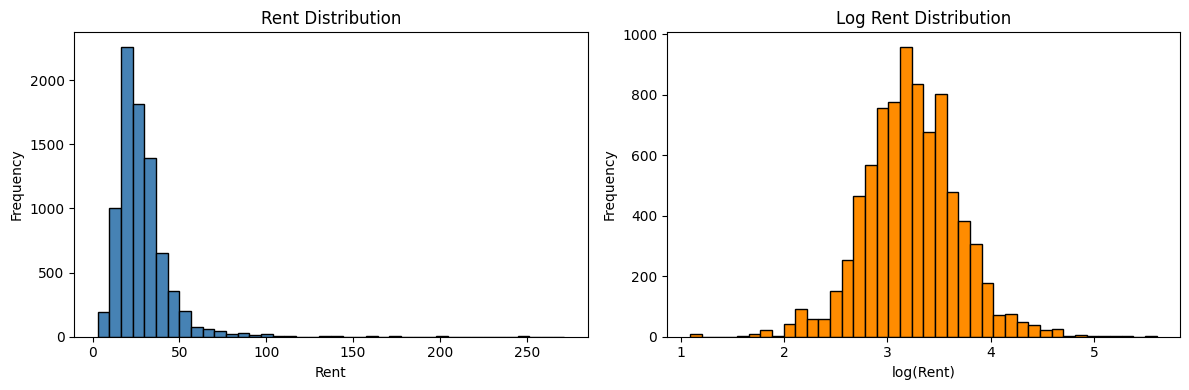

In [142]:
# Compare raw rent and logged rent distributions
fig, axes = subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Rent'], bins=40, color='steelblue', edgecolor='black')
axes[0].set_title('Rent Distribution')
axes[0].set_xlabel('Rent')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['log_rent'], bins=40, color='darkorange', edgecolor='black')
axes[1].set_title('Log Rent Distribution')
axes[1].set_xlabel('log(Rent)')
axes[1].set_ylabel('Frequency')

fig.tight_layout()

In [143]:
df_dropna = df.dropna(subset=['empl_gr', 'stories', 'age'])

In [144]:
df_dropna.isnull().sum()

CS_PropertyID           0
id                      0
idgreen              7141
EPA_ID               7344
size                    0
empl_gr                 0
Rent                    0
leasing_rate            0
stories                 0
age                     0
renovated               0
class_a                 0
class_b                 0
class_c                 0
LEED                    0
Energystar              0
green_rating            0
net                     0
amenities               0
cd_total_07             0
hd_total07              0
total_dd_07             0
Precipitation           0
Gas_Costs               0
Electricity_Costs       0
SEP_Rating           7374
SEP_current          7387
Electricity          7374
Natural_Gas          7374
Other_Energy         7374
Site_EUI             7374
Source_EUI           7374
Emissions            7374
log_rent                0
size_000                0
high_rise               0
mid_rise                0
age_under_10            0
age_10_20   

In [145]:
not_to_include = [
    'CS_PropertyID',
    'idgreen',
    'EPA_ID',
    'LEED', 
    'Energystar'
    'class_c', # Omitted category for class
    'SEP_Rating',
    'SEP_current',
    'Electricity',
    'Natural_Gas',
    'Other_Energy',
    'Site_EUI ',
    'Source_EUI',
    'Emissions ',
    'Rent'
]

# cols = ['Rent', 'log_rent', 'green_rating', 'size', 'age', 'stories', 'renovated',
#         'class_a', 'class_b', 'net', 'amenities', 'leasing_rate',
#         'empl_gr', 'cd_total_07', 'hd_total07', 'Precipitation',
#         'Gas_Costs', 'Electricity_Costs']

cols = ['Rent', 'log_rent', 'green_rating', 'size_000', 'age_under_10', 'age_10_20', 
        'age_20_30', 'age_30_40', 'mid_rise', 'high_rise', 'renovated',
        'class_a', 'class_b', 'net', 'amenities', 'leasing_rate']

In [146]:
seed = 42

In [147]:
df_train, df_test = skm.train_test_split(
    df, test_size=0.2, random_state=seed, stratify=df['green_rating']
)

In [148]:
cluster_means_train = df_train.groupby('id')[cols].transform('mean')
df_train_demeaned = df_train[cols] - cluster_means_train

cluster_means_test = df_test.groupby('id')[cols].transform('mean')
df_test_demeaned = df_test[cols] - cluster_means_test

# OLS

In [59]:
df_ols = df_dropna[cols + ['id']].copy()

cluster_means = df_ols.groupby('id')[cols].transform('mean')
df_ols_demeaned = df_ols[cols] - cluster_means

y_ols = df_ols_demeaned['log_rent']
X_ols = df_ols_demeaned.drop(columns=['Rent', 'log_rent'])

In [153]:
df_ols = df[cols + ['id']].copy()

y_ols = df_ols['log_rent']
X_ols = df_ols.drop(columns=['Rent', 'log_rent', 'id'])
id_dummies = pd.get_dummies(df_ols['id'], prefix='id', drop_first=True, dtype=int)
X_ols = pd.concat([X_ols, id_dummies], axis=1)

In [154]:

X_ols_const = sm.add_constant(X_ols)
model = sm.OLS(y_ols, X_ols_const)

In [155]:
results = model.fit(cov_type='cluster', cov_kwds={'groups': df_ols['id']}, use_t=True)

In [156]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:               log_rent   R-squared:                       0.720
Model:                            OLS   Adj. R-squared:                  0.693
Method:                 Least Squares   F-statistic:                     841.7
Date:                Mon, 28 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:18:47   Log-Likelihood:                 9.1535
No. Observations:                8183   AIC:                             1398.
Df Residuals:                    7475   BIC:                             6361.
Df Model:                         707                                         
Covariance Type:              cluster                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            3.3300      0.021    159.096   

/opt/anaconda3/envs/pydata/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 707, but rank is 14
  warnings.warn('covariance of constraints does not have full '


In [37]:
print(results.summary().as_latex())

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}    &    log\_rent     & \textbf{  R-squared:         } &     0.159   \\
\textbf{Model:}            &       OLS        & \textbf{  Adj. R-squared:    } &     0.157   \\
\textbf{Method:}           &  Least Squares   & \textbf{  F-statistic:       } &     82.10   \\
\textbf{Date:}             & Sun, 27 Sep 2026 & \textbf{  Prob (F-statistic):} & 3.71e-136   \\
\textbf{Time:}             &     22:10:51     & \textbf{  Log-Likelihood:    } &    203.76   \\
\textbf{No. Observations:} &        7820      & \textbf{  AIC:               } &    -377.5   \\
\textbf{Df Residuals:}     &        7805      & \textbf{  BIC:               } &    -273.0   \\
\textbf{Df Model:}         &          14      & \textbf{                     } &             \\
\textbf{Covariance Type:}  &     cluster      & \textbf{                     } &             \\
\bottomrule
\end{tabular}
\begin{tabular}{lcccccc}
                        & \textbf{coef}

In [66]:
tbl = results.summary2().tables[1].loc[key_vars].rename(index=labels)
tbl = tbl.rename(index={"Size (sq. ft.)": "Size (thousands of sq. ft.)"})
tbl.columns = ["Coef.", "Std. Err.", "t", "$P>|t|$", "[0.025", "0.975]"]
tbl.index.name = "Variable"

latex = tbl.to_latex(
    float_format="%.4f",
    escape=False,
    label="tab:ols",
    position="H",
    caption=("OLS results with cluster fixed effects, dependent variable: log rent. "
             "Coefficients on building age, stories, renovation, and occupancy are estimated "
             "but omitted from the table. "
             f"N = {int(results.nobs):,}; $R^2$ = {results.rsquared:.3f}."),
)
print(latex)
with open("ols_table.tex", "w") as f:
    f.write(latex)

\begin{table}[H]
\caption{OLS results with cluster fixed effects, dependent variable: log rent. Coefficients on building age, stories, renovation, and occupancy are estimated but omitted from the table. N = 7,820; $R^2$ = 0.730.}
\label{tab:ols}
\begin{tabular}{lrrrrrr}
\toprule
 & Coef. & Std. Err. & t & $P>|t|$ & [0.025 & 0.975] \\
Variable &  &  &  &  &  &  \\
\midrule
Green rating & 0.0245 & 0.0090 & 2.7308 & 0.0065 & 0.0069 & 0.0421 \\
Size (thousands of sq. ft.) & 0.0001 & 0.0000 & 3.1460 & 0.0017 & 0.0000 & 0.0001 \\
Class A & 0.1453 & 0.0158 & 9.1797 & 0.0000 & 0.1143 & 0.1764 \\
Class B & 0.0660 & 0.0123 & 5.3777 & 0.0000 & 0.0419 & 0.0901 \\
Net contract & -0.0414 & 0.0170 & -2.4266 & 0.0155 & -0.0748 & -0.0079 \\
Amenities & 0.0416 & 0.0077 & 5.4008 & 0.0000 & 0.0265 & 0.0567 \\
\bottomrule
\end{tabular}
\end{table}



/opt/anaconda3/envs/pydata/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 701, but rank is 14
  warnings.warn('covariance of constraints does not have full '


# Ridge

In [157]:
df_model = df[cols + ['id']].copy()

gss = skm.GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
train_idx, test_idx = next(gss.split(df_model, groups=df_model['id']))

In [202]:
df_train = df_model.iloc[train_idx]
df_test = df_model.iloc[test_idx]

X = df_model.drop(columns=['Rent', 'log_rent', 'id'])
y = df_model['log_rent']

X_train = df_train.drop(columns=['Rent', 'log_rent', 'id'])
X_test = df_test.drop(columns=['Rent', 'log_rent', 'id'])

y_train = df_train['log_rent']
y_test = df_test['log_rent']

In [235]:
cluster_means_train = df_train.groupby('id')[cols].transform('mean')
df_train_demeaned = df_train[cols] - cluster_means_train

cluster_means_test = df_test.groupby('id')[cols].transform('mean')
df_test_demeaned = df_test[cols] - cluster_means_test
X_train_demeaned = df_train_demeaned - cluster_means_train
X_test_demeaned = df_test_demeaned - cluster_means_test

cluster_means_df_model = df_model.groupby('id')[cols].transform('mean')
df_model_demeaned = df_model[cols] - cluster_means_df_model

X_demeaned = df_model_demeaned.drop(columns=['Rent', 'log_rent'])
y_demeaned = df_model_demeaned['log_rent']

In [241]:
K = 5

gkf = skm.GroupKFold(n_splits=K)
cv_splits = list(gkf.split(X_train, y_train, groups=df_train['id']))


kfold = skm.KFold(K,
                  random_state=0,
                  shuffle=True)

In [236]:
scaler = StandardScaler()
Xs = scaler.fit_transform(df_model_demeaned.drop(columns=['Rent', 'log_rent']))
y_demeaned = df_model_demeaned['log_rent']

In [256]:
alphas = 10**np.linspace(8, -2, 100) / y_demeaned.std()

soln_array = skl.ElasticNet.path(Xs,
                                 y_demeaned,
                                 l1_ratio=0.,
                                 alphas=alphas)[1]
soln_array.shape

/opt/anaconda3/envs/pydata/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/envs/pydata/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.803e+02, tolerance: 5.605e-02
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/envs/pydata/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/envs/

(14, 100)

In [257]:


soln_path = pd.DataFrame(soln_array.T,
                         columns=df_model.drop(columns=['Rent', 'log_rent', 'id']).columns,
                         index=-np.log(alphas))
soln_path.index.name = 'negative log(lambda)'
soln_path

,green_rating,size_000,age_under_10,age_10_20,age_20_30,age_30_40,mid_rise,high_rise,renovated,class_a,class_b,net,amenities,leasing_rate
negative log(lambda),,,,,,,,,,,,,,
-19.761106,8.428897e-11,1.804341e-10,6.546883e-11,8.321919e-11,7.263795e-11,3.391563e-11,-3.063873e-12,1.515006e-10,-6.013549e-11,2.182673e-10,-9.111633e-11,1.385296e-11,1.518714e-10,8.073100e-11
-19.528522,1.063606e-10,2.276819e-10,8.261229e-11,1.050107e-10,9.165869e-11,4.279667e-11,-3.866169e-12,1.911721e-10,-7.588238e-11,2.754221e-10,-1.149758e-10,1.748045e-11,1.916400e-10,1.018710e-10
-19.295938,1.342119e-10,2.873020e-10,1.042449e-10,1.325085e-10,1.156602e-10,5.400327e-11,-4.878552e-12,2.412318e-10,-9.575270e-11,3.475432e-10,-1.450830e-10,2.205782e-11,2.418222e-10,1.285466e-10
-19.063353,1.693562e-10,3.625340e-10,1.315421e-10,1.672067e-10,1.459466e-10,6.814440e-11,-6.156034e-12,3.044001e-10,-1.208262e-10,4.385498e-10,-1.830739e-10,2.783382e-11,3.051450e-10,1.622074e-10
-18.830769,2.137033e-10,4.574661e-10,1.659873e-10,2.109910e-10,1.841637e-10,8.598848e-11,-7.768033e-12,3.841093e-10,-1.524654e-10,5.533871e-10,-2.310131e-10,3.512229e-11,3.850494e-10,2.046825e-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2.334407,7.398823e-03,2.405834e-02,2.177077e-02,1.863174e-02,1.603824e-02,8.459621e-03,1.541966e-02,1.388215e-02,-5.215614e-03,5.339416e-02,2.208120e-02,-7.681924e-03,1.980479e-02,2.876154e-03
2.566991,7.307481e-03,2.401566e-02,2.212935e-02,1.894433e-02,1.629799e-02,8.661541e-03,1.560142e-02,1.360465e-02,-5.169992e-03,5.587582e-02,2.411494e-02,-7.935906e-03,1.972131e-02,2.545224e-03
2.799576,7.224969e-03,2.394694e-02,2.239607e-02,1.917563e-02,1.647940e-02,8.816907e-03,1.571166e-02,1.332187e-02,-5.138284e-03,5.813586e-02,2.594679e-02,-8.145198e-03,1.962304e-02,2.255177e-03


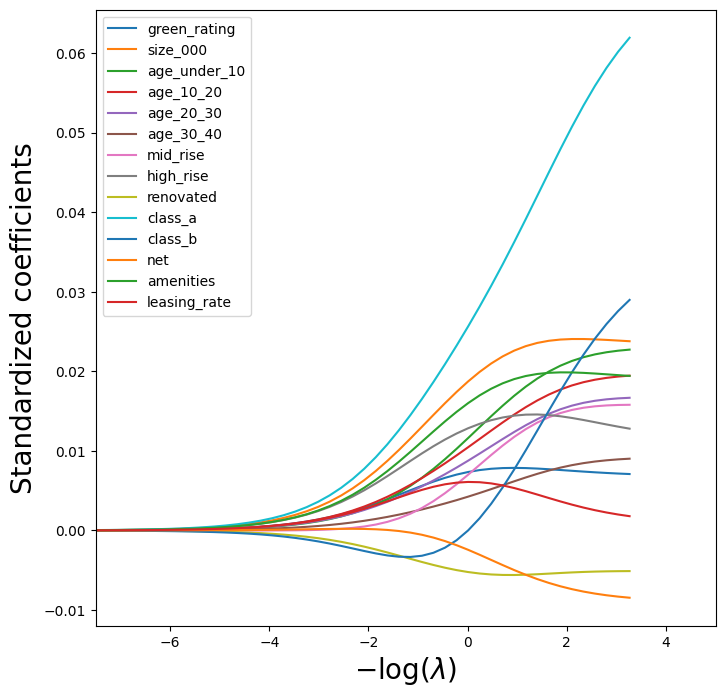

In [265]:
path_fig, ax = subplots(figsize=(8,8))
soln_path.plot(ax=ax, legend=False)
ax.set_xlabel(r'$-\log(\lambda)$', fontsize=20)
ax.set_xlim([-7.5, 5])
ax.set_ylabel('Standardized coefficients', fontsize=20)
ax.legend(loc='upper left');


In [260]:
ridge = skl.ElasticNet(l1_ratio=0)
scaler = StandardScaler(with_mean=True,  with_std=True)
pipe = Pipeline(steps=[('scaler', scaler), ('ridge', ridge)])
pipe.fit(X_demeaned, y_demeaned)


/opt/anaconda3/envs/pydata/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.535e+02, tolerance: 5.605e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",1.0
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False


In [261]:
ridge_results = skm.cross_validate(
    pipe, X_demeaned, y_demeaned, cv=kfold, scoring='neg_mean_squared_error'
)
-ridge_results['test_score'].mean()

/opt/anaconda3/envs/pydata/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.004e+02, tolerance: 4.450e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/pydata/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.063e+02, tolerance: 4.546e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.l

np.float64(0.06020372979243214)

In [262]:
param_grid = {'ridge__alpha': alphas}

grid = skm.GridSearchCV(
    pipe,
    param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_demeaned, y_demeaned)
grid.best_params_['ridge__alpha']
grid.best_estimator_

/opt/anaconda3/envs/pydata/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.190e+02, tolerance: 4.381e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/pydata/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.267e+02, tolerance: 4.534e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.l

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",np.float64(0....6694347513795)
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False


In [263]:
-grid.best_score_

np.float64(0.05879428249153068)

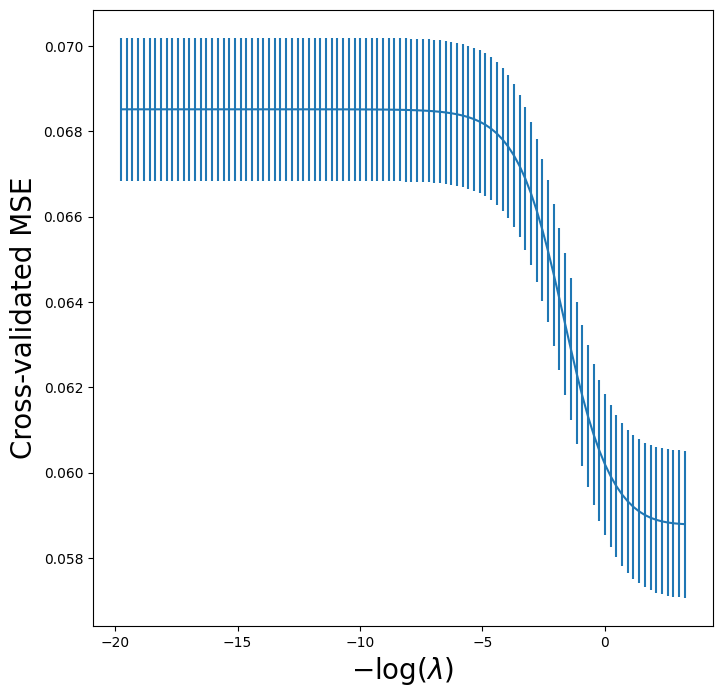

In [264]:
ridge_fig, ax = subplots(figsize=(8,8))
ax.errorbar(-np.log(alphas),
            -grid.cv_results_['mean_test_score'],
            yerr=grid.cv_results_['std_test_score'] / np.sqrt(K))
# ax.set_ylim([0.15,0.25])
ax.set_xlabel(r'$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('Cross-validated MSE', fontsize=20);

# Lasso

In [246]:
lassoCV = skl.ElasticNetCV(
    n_alphas=100,
    l1_ratio=1,
    cv=kfold
)

pipe_cv = Pipeline(
    steps=[('scaler', scaler), ('lasso', lassoCV)]
)
pipe_cv.fit(X_demeaned, y_demeaned)
tuned_lasso = pipe_cv.named_steps['lasso']
tuned_lasso.alpha_

/opt/anaconda3/envs/pydata/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


np.float64(0.000336657807742804)

In [249]:
scaler_fitted = pipe_cv.named_steps['scaler']
X_demeaned_scaled = scaler_fitted.transform(X_demeaned)

In [250]:
alphas, soln_array = skl.Lasso.path(X_demeaned_scaled,
                                    y_demeaned,
                                    l1_ratio=1,
                                    n_alphas=100)[:2]
soln_path = pd.DataFrame(soln_array.T,
                         columns=X_demeaned.columns,
                         index=-np.log(alphas))

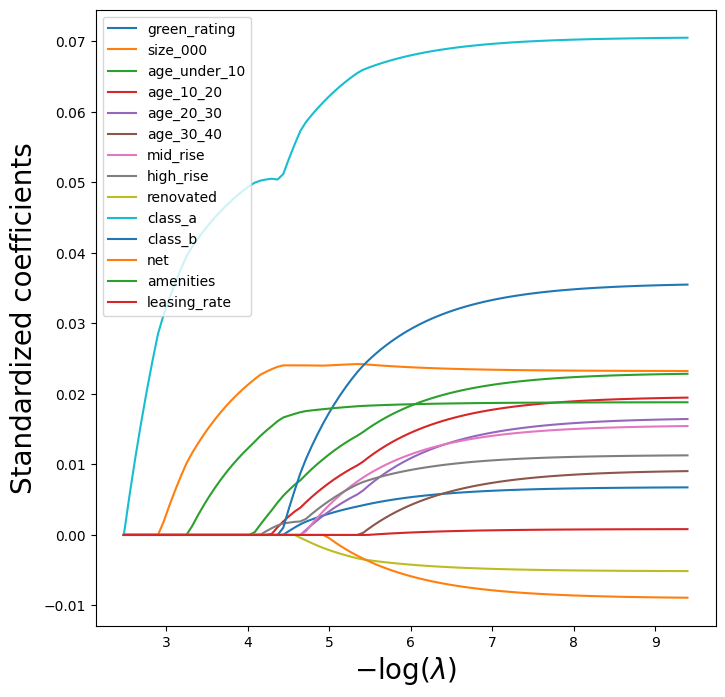

In [251]:
path_fig, ax = subplots(figsize=(8,8))
soln_path.plot(ax=ax, legend=False)
ax.legend(loc='upper left')
ax.set_xlabel(r'$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('Standardized coefficients', fontsize=20);


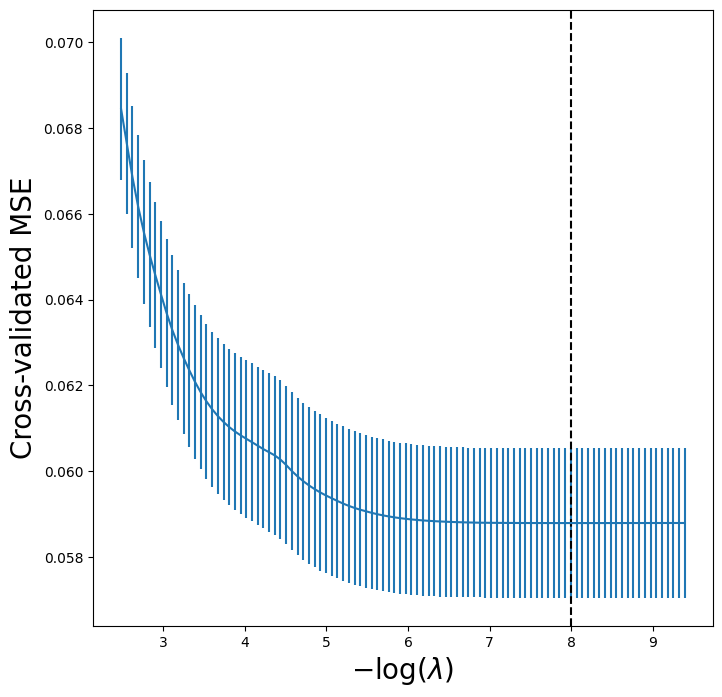

In [252]:
lassoCV_fig, ax = subplots(figsize=(8,8))
ax.errorbar(-np.log(tuned_lasso.alphas_),
            tuned_lasso.mse_path_.mean(1),
            yerr=tuned_lasso.mse_path_.std(1) / np.sqrt(K))
ax.axvline(-np.log(tuned_lasso.alpha_), c='k', ls='--')
# ax.set_ylim([50000,250000])
ax.set_xlabel(r'$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('Cross-validated MSE', fontsize=20);

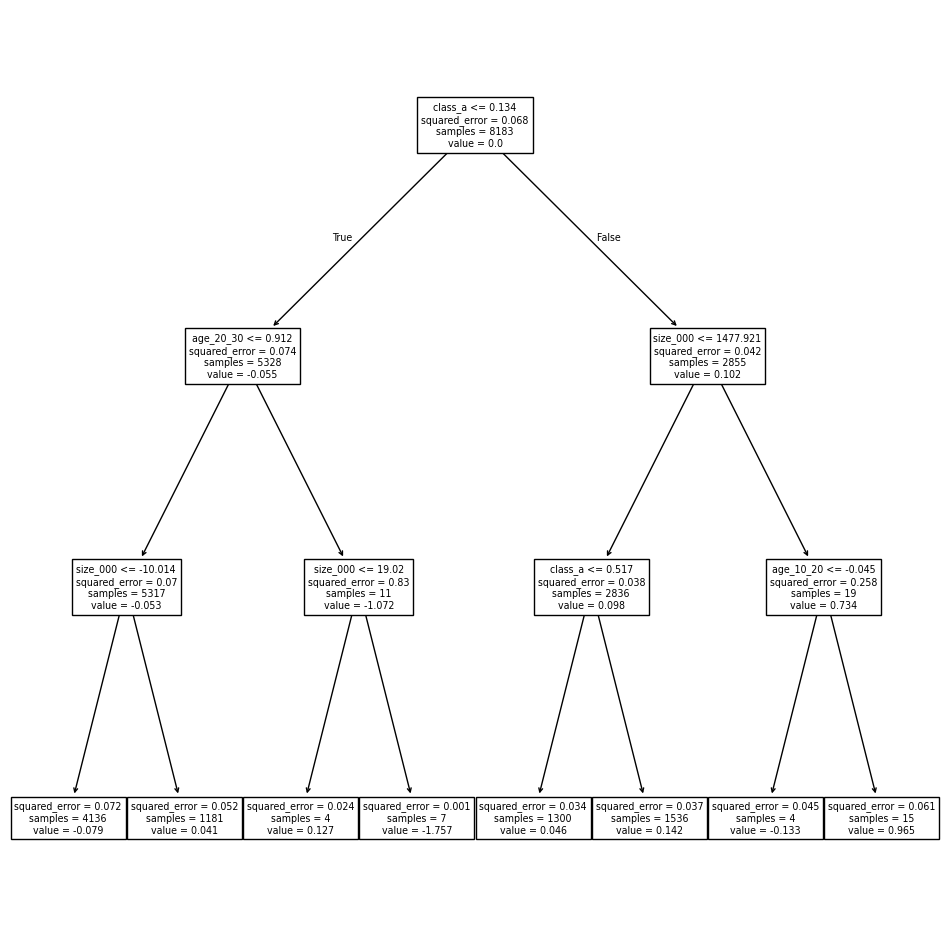

In [267]:
tree = DTR(max_depth=3)
tree.fit(X_demeaned, y_demeaned)
ax = subplots(figsize=(12,12))[1]
plot_tree(tree,
          feature_names=X.columns,
          ax=ax);

# Title

In [269]:
rf = RF(max_features=5, random_state=seed)
rf.fit(X_demeaned, y_demeaned)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [270]:
feature_imp = pd.DataFrame(
    {'importance':rf.feature_importances_},
    index=X_demeaned.columns)
feature_imp.sort_values(by='importance', ascending=False)

,importance
size_000,0.175263
leasing_rate,0.122217
class_a,0.106689
renovated,0.078228
amenities,0.072819
age_20_30,0.071990
class_b,0.067663
mid_rise,0.062244
high_rise,0.057486
green_rating,0.045655
